# 0.1 Release Showcase

This will be a high-level showcase of how you can leverage **fastdist** for various programmatical tasks. 

If you would like to download the library or run this code yourself, please follow the instructions on the **README**. 

Additionally, if you would like to contribute to our project, you can feel free to fork our repo and make a pull request with your requested changes/fixes.

Note that this was run on a Mac, so none of the CUDA support will be shown directly here. Nonetheless, expect a CUDA example notebook in the future, especially as we introduce more CUDA modules and functionality.

With that said, let's explore **fastdist**.

In [1]:
# Other libraries I will use for the showcase
import numpy as np
import matplotlib.pyplot as plt

## Basic Sampling & Importing
All I would have to do is run `import fastdist` and then I would have access to the full library. However, I am going to use specific module imports for this showcase for the sake of efficiency and cleanliness here.

Now, let's start by collecting some basic samples from a normal distribution.

In [3]:
# Let's create an instance of a normal distribution class centered at 100 with a std of 15
# This is, essentially, what the normal curve for IQ looks like
# Note: If you get a warning regarding pvnml, you can disregard it
from fastdist import Normal 

print("\n" + "=" * 80)
print("1. BASIC SAMPLING AND Z-SCORES")
print("=" * 80)
norm_dist = Normal(mu=100, sigma=15)

# Bonus: I can also check if I have CUDA available on my machine
print(f"\nCUDA Available: {norm_dist.is_cuda_available()}")
print("(False on Mac, but True on CUDA-enabled systems for a speedup)")


1. BASIC SAMPLING AND Z-SCORES

CUDA Available: False
(False on Mac, but True on CUDA-enabled systems for a speedup)


In [4]:
# Now let's take a quick, small sample via RNG and see what we get
sample_1 = norm_dist.sample()
sample_2 = norm_dist.sample() 
sample_3 = norm_dist.sample()

print("\nThree random IQ samples:")
print(f"Sample 1: {sample_1:.2f}")
print(f"Sample 2: {sample_2:.2f}")
print(f"Sample 3: {sample_3:.2f}")

# Let's check their z-scores now
print("\nZ-scores (standard deviations from mean):")
print(f"Sample 1 z-score: {norm_dist.z_score(sample_1):+.3f}")
print(f"Sample 2 z-score: {norm_dist.z_score(sample_2):+.3f}")
print(f"Sample 3 z-score: {norm_dist.z_score(sample_3):+.3f}")


Three random IQ samples:
Sample 1: 110.60
Sample 2: 87.51
Sample 3: 95.56

Z-scores (standard deviations from mean):
Sample 1 z-score: +0.707
Sample 2 z-score: -0.833
Sample 3 z-score: -0.296


## More Sampling, Graphing with PDF & CDF
The sampling looks reasonable, but let's really give it a stress test by graphing the shape.

We can do this via two ways:
- Using the PDF
- Using sampling (RNG)

...let's do both

Method 1: Using PDF to plot the theoretical curve...


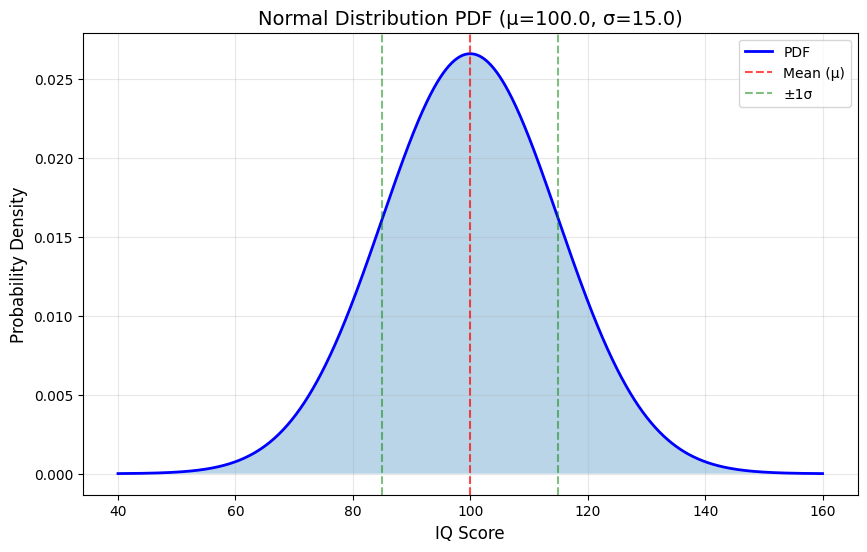

In [5]:
# METHOD 1: Using PDF (Probability Density Function)
print("Method 1: Using PDF to plot the theoretical curve...")
x = np.linspace(norm_dist.mu - 4*norm_dist.sigma, 
                norm_dist.mu + 4*norm_dist.sigma, 
                1000)
pdf_values = norm_dist.pdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_values, 'b-', linewidth=2, label='PDF')
plt.fill_between(x, pdf_values, alpha=0.3)
plt.axvline(norm_dist.mu, color='red', linestyle='--', alpha=0.7, label='Mean (μ)')
plt.axvline(norm_dist.mu - norm_dist.sigma, color='green', linestyle='--', alpha=0.5, label='±1σ')
plt.axvline(norm_dist.mu + norm_dist.sigma, color='green', linestyle='--', alpha=0.5)
plt.title(f'Normal Distribution PDF (μ={norm_dist.mu}, σ={norm_dist.sigma})', fontsize=14)
plt.xlabel('IQ Score', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Method 2: Using sampling to verify the distribution...


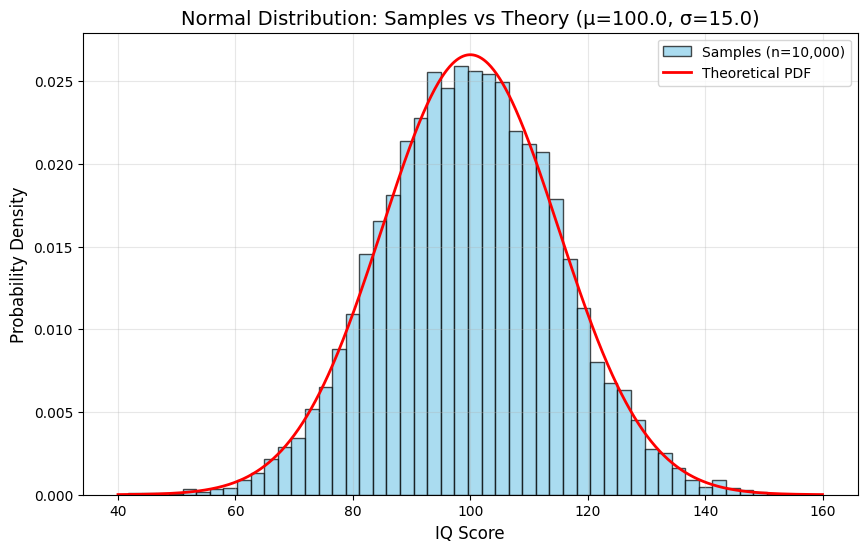


Sample mean: 99.940 (expected: 100.0)
Sample std: 14.984 (expected: 15.0)


In [6]:
# METHOD 2: Using Sampling
print("Method 2: Using sampling to verify the distribution...")
# You can change the number of samples here
n_samples = 10000
samples = np.array([norm_dist.sample() for _ in range(n_samples)])

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label=f'Samples (n={n_samples:,})')
plt.plot(x, pdf_values, 'r-', linewidth=2, label='Theoretical PDF')
plt.title(f'Normal Distribution: Samples vs Theory (μ={norm_dist.mu}, σ={norm_dist.sigma})', fontsize=14)
plt.xlabel('IQ Score', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# These should be very close to our theoretical mean and std (Law of Large Numbers)
# While this isn't a rigorous proof, it's a scientifically-grounded observation of the property
print(f"\nSample mean: {samples.mean():.3f} (expected: {norm_dist.mu})")
print(f"Sample std: {samples.std():.3f} (expected: {norm_dist.sigma})")

As you can see, the PDF function is powerful if you want to evaluate a distribution’s y-value at a certain point. The CDF can also be extremely useful for evaluating different calculations and, effectively, the area under the curve (of the PDF) at a given x.


3. PDF AND CDF EVALUATION

PDF Values (probability density):
  At mean (100): 0.026596
  At 115 (+1σ):  0.016131
  At 85 (-1σ):   0.016131

CDF Values (cumulative probability):
  P(IQ ≤ 100) = 0.5000 (50th percentile)
  P(IQ ≤ 115) = 0.8413 (84th percentile)
  P(IQ ≤ 130) = 0.9772 (98th percentile)

==== CDF Visualization ====


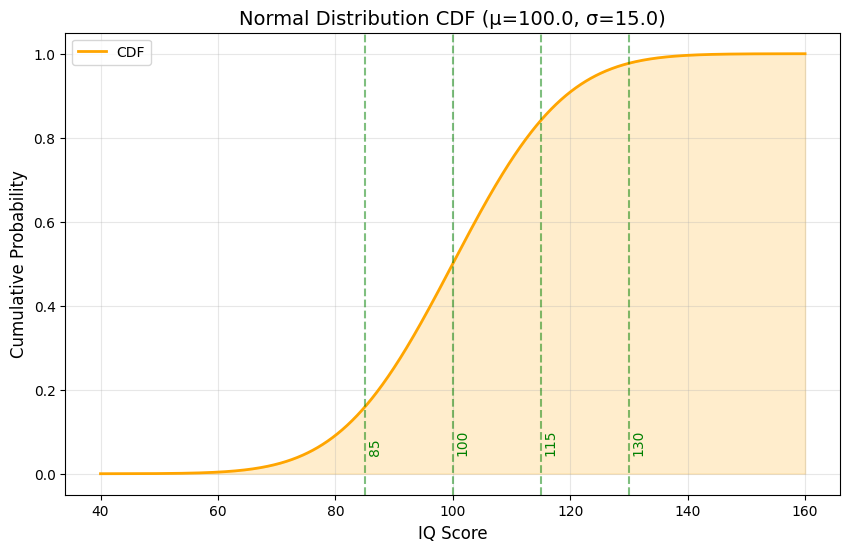

In [7]:
print("\n" + "=" * 80)
print("3. PDF AND CDF EVALUATION")
print("=" * 80)

# Evaluate PDF at specific points
print(f"\nPDF Values (probability density):")
print(f"  At mean (100): {norm_dist.pdf(100):.6f}")
print(f"  At 115 (+1σ):  {norm_dist.pdf(115):.6f}")
print(f"  At 85 (-1σ):   {norm_dist.pdf(85):.6f}")

# Evaluate CDF (cumulative probability)
print(f"\nCDF Values (cumulative probability):")
print(f"  P(IQ ≤ 100) = {norm_dist.cdf(100):.4f} (50th percentile)")
print(f"  P(IQ ≤ 115) = {norm_dist.cdf(115):.4f} (84th percentile)")
print(f"  P(IQ ≤ 130) = {norm_dist.cdf(130):.4f} (98th percentile)")

# CDF Graphing
print()
print("==== CDF Visualization ====")

# Define x range around mean ±4σ
x = np.linspace(norm_dist.mu - 4*norm_dist.sigma, 
                norm_dist.mu + 4*norm_dist.sigma, 
                1000)
cdf_values = norm_dist.cdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, cdf_values, 'orange', linewidth=2, label='CDF')
plt.fill_between(x, cdf_values, alpha=0.2, color='orange')

# Vertical lines at key points
for iq in [85, 100, 115, 130]:
    plt.axvline(iq, color='green', linestyle='--', alpha=0.5)
    plt.text(iq+0.5, 0.05, f'{iq}', rotation=90, color='green', fontsize=10)

# Labels, title, grid
plt.title(f'Normal Distribution CDF (μ={norm_dist.mu}, σ={norm_dist.sigma})', fontsize=14)
plt.xlabel('IQ Score', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [8]:
# Probability between two values
prob_68 = norm_dist.cdf(115) - norm_dist.cdf(85)
prob_95 = norm_dist.cdf(130) - norm_dist.cdf(70)
# Another observation... the empirical rule!
print(f"\nInterval probabilities:")
print(f"  P(85 ≤ IQ ≤ 115) = {prob_68:.4f} (~68% rule: μ±1σ)")
print(f"  P(70 ≤ IQ ≤ 130) = {prob_95:.4f} (~95% rule: μ±2σ)")


Interval probabilities:
  P(85 ≤ IQ ≤ 115) = 0.6827 (~68% rule: μ±1σ)
  P(70 ≤ IQ ≤ 130) = 0.9545 (~95% rule: μ±2σ)


## Basic Vectorized Operations
We didn’t just code this in C++ for no reason. We wanted speed. These vectorized operations (and especially CUDA usage) are really where our library shines. We are going to continue optimizing these functions, on both the GPU and CPU levels, as we move forward in development.

Special shoutout to NumPy, which makes everything even faster!

In [9]:
# ============================================================================
# 4. VECTORIZED OPERATIONS
# ============================================================================
print("\n" + "=" * 80)
print("=" * 80)

# Calculate PDF for multiple IQ scores at once
iq_scores = np.array([70, 85, 100, 115, 130, 145])
pdf_vals = norm_dist.pdf(iq_scores)
cdf_vals = norm_dist.cdf(iq_scores)

print("IQ Score Analysis (vectorized):")
print("-" * 60)
print(f"{'IQ':<6} {'PDF':<12} {'CDF':<12} {'Percentile'}")
print("-" * 60)
for iq, pdf, cdf in zip(iq_scores, pdf_vals, cdf_vals):
    print(f"{iq:<6.0f} {pdf:<12.6f} {cdf:<12.4f} {cdf*100:>5.1f}%")


IQ Score Analysis (vectorized):
------------------------------------------------------------
IQ     PDF          CDF          Percentile
------------------------------------------------------------
70     0.003599     0.0228         2.3%
85     0.016131     0.1587        15.9%
100    0.026596     0.5000        50.0%
115    0.016131     0.8413        84.1%
130    0.003599     0.9772        97.7%
145    0.000295     0.9987        99.9%


## Advanced Operations

Below are some more advanced operations that you can perform. These may vary depending on which distribution you use. Some distributions do not have closed-form MGFs, so we do not yet have coded solutions for those; the normal distribution provides some additional functionality that is also available in some of the other distributions.

As mentioned earlier, we will continue expanding functionality over time. This is just a partial showcase of our 0.1 launch.

In [10]:
# ============================================================================
# 5. ADVANCED: MGF, CGF, AND LOG-PDF
# ============================================================================
print("\n" + "=" * 80)
print("5. ADVANCED FUNCTIONS: MGF, CGF, LOG-PDF")
print("=" * 80)

# Log-PDF is more numerically stable for likelihood calculations
print("\nLog-PDF (for likelihood calculations):")
logpdf_vals = norm_dist.logpdf(iq_scores)
for iq, logpdf in zip(iq_scores, logpdf_vals):
    print(f"  log(PDF) at IQ={iq}: {logpdf:.4f}")

# Moment Generating Function
# Basically the Laplace transform
print("\nMoment Generating Function (MGF):")
t_vals = np.array([0.0, 0.01, 0.02])
mgf_vals = norm_dist.mgf(t_vals)
for t, mgf in zip(t_vals, mgf_vals):
    print(f"  MGF(t={t:.2f}) = {mgf:.6f}")

# Cumulant Generating Function
print("\nCumulant Generating Function (CGF):")
cgf_vals = norm_dist.cgf(t_vals)
for t, cgf in zip(t_vals, cgf_vals):
    print(f"  CGF(t={t:.2f}) = {cgf:.6f}")


5. ADVANCED FUNCTIONS: MGF, CGF, LOG-PDF

Log-PDF (for likelihood calculations):
  log(PDF) at IQ=70: -5.6270
  log(PDF) at IQ=85: -4.1270
  log(PDF) at IQ=100: -3.6270
  log(PDF) at IQ=115: -4.1270
  log(PDF) at IQ=130: -5.6270
  log(PDF) at IQ=145: -8.1270

Moment Generating Function (MGF):
  MGF(t=0.00) = 1.000000
  MGF(t=0.01) = 2.749035
  MGF(t=0.02) = 7.729159

Cumulant Generating Function (CGF):
  CGF(t=0.00) = 0.000000
  CGF(t=0.01) = 1.011250
  CGF(t=0.02) = 2.045000


## Basic Utilities (1)
We also have some utility functions that can help you with basic statistical housekeeping and evaluation.

In [11]:
from fastdist import Utils

# Example Normal distribution
norm_dist = Normal(mu=0, sigma=1)

print("\n" + "=" * 80)
print("6. UTILITY FUNCTIONS FROM FASTDIST.UTILS")
print("=" * 80)

# Chebyshev's Inequality
k = 2
chebyshev_bound = Utils.chebyshev_bound(norm_dist.variance(), k)
actual_prob = 1 - (norm_dist.cdf(norm_dist.mu + k*norm_dist.sigma) - 
                    norm_dist.cdf(norm_dist.mu - k*norm_dist.sigma))
print(f"Chebyshev's Inequality (k={k}):")
print(f"  Upper bound: P(|X - μ| ≥ 2σ) ≤ {chebyshev_bound:.4f}")
print(f"  Actual (Normal): {actual_prob:.4f}")

# Coefficient of Variation
# Yes, this should be NaN because we attempt division by zero
cv = Utils.coefficient_of_variation(norm_dist.mean(), norm_dist.stddev())
print(f"\nCoefficient of Variation: {cv:.4f}")

# Combinatorial functions
print(f"\nCombinatorial Functions:")
print(f"  C(10, 3) = {Utils.choose(10, 3):.0f}")
print(f"  P(10, 3) = {Utils.permutation(10, 3):.0f}")
print(f"  10! = {Utils.factorial(10):.0f}")

# Distance metrics
x = [1.0, 2.0, 3.0]
y = [4.0, 5.0, 6.0]

print(f"\nEuclidean distance: {Utils.euclidean_distance(x, y):.4f}")
print(f"Manhattan distance: {Utils.manhattan_distance(x, y):.4f}")
print(f"Cosine similarity: {Utils.cosine_similarity(x, y):.4f}")

# It also works with NumPy arrays
x = np.array([3, 5])
y = np.array([2, 7])
print(f"\nEuclidean distance w/ NumPy: {Utils.euclidean_distance(x, y):.4f}")


6. UTILITY FUNCTIONS FROM FASTDIST.UTILS
Chebyshev's Inequality (k=2):
  Upper bound: P(|X - μ| ≥ 2σ) ≤ 0.2500
  Actual (Normal): 0.0455

Coefficient of Variation: nan

Combinatorial Functions:
  C(10, 3) = 120
  P(10, 3) = 720
  10! = 3628800

Euclidean distance: 5.1962
Manhattan distance: 9.0000
Cosine similarity: 0.9746

Euclidean distance w/ NumPy: 2.2361


In [12]:
# Coefficient of variation (but with a real number output this time)
norm_dist = Normal(mu=5, sigma=1)
cv = Utils.coefficient_of_variation(norm_dist.mean(), norm_dist.stddev())
cv = Utils.coefficient_of_variation(norm_dist.mean(), norm_dist.stddev())
print(f"\nCoefficient of Variation: {cv:.4f}")


Coefficient of Variation: 0.2000


## Poisson Distribution Calculations and Graphing
We have many other distributions that you can utilize on top of our normal distribution support, so let's try some! One of my personal favorite distributions is the Poisson distribution, so let's start with that.

In [13]:
from fastdist.distributions import Poisson

# Example Poisson distribution
lambda_val = 4.5
poisson_dist = Poisson(lambda_=lambda_val)

print("\n" + "=" * 80)
print("7. POISSON DISTRIBUTION SHOWCASE")
print("=" * 80)

# PMF for individual values
x_vals = [0, 1, 2, 3, 4, 5, 6, 7]
pmf_vals = poisson_dist.pmf(x_vals)
print("\nPoisson PMF (λ = {:.1f}):".format(lambda_val))
print("-" * 60)
print(f"{'x':<4} {'PMF':<12}")
print("-" * 60)
for x, pmf in zip(x_vals, pmf_vals):
    print(f"{x:<4} {pmf:<12.6f}")

# CDF for the same values
cdf_vals = poisson_dist.cdf(x_vals)
print("\nPoisson CDF (λ = {:.1f}):".format(lambda_val))
print("-" * 60)
print(f"{'x':<4} {'CDF':<12}")
print("-" * 60)
for x, cdf in zip(x_vals, cdf_vals):
    print(f"{x:<4} {cdf:<12.6f}")

# Mean, Variance, StdDev
print("\nStatistical Moments:")
print("-" * 60)
print(f"Mean:     {poisson_dist.mean():.4f}")
print(f"Variance: {poisson_dist.variance():.4f}")
print(f"Std Dev:  {poisson_dist.stddev():.4f}")

# MGF and CGF at t = 0.5
t = 0.5
print("\nMoment Generating Functions:")
print("-" * 60)
print(f"MGF(t={t}): {poisson_dist.mgf(t):.6f}")
print(f"CGF(t={t}): {poisson_dist.cgf(t):.6f}")

# Sampling
n_samples = 5
samples = [poisson_dist.sample() for _ in range(n_samples)]
print("\nRandom Samples (n={}): {}".format(n_samples, samples))

# Chebyshev's Inequality (example)
k = 2
chebyshev_bound = Utils.chebyshev_bound(poisson_dist.variance(), k)
actual_prob = 1 - (poisson_dist.cdf(poisson_dist.mean() + k * poisson_dist.stddev()) -
                   poisson_dist.cdf(poisson_dist.mean() - k * poisson_dist.stddev()))
print("\nChebyshev's Inequality (k={}):".format(k))
print(f"  Upper bound: P(|X - μ| ≥ {k}σ) ≤ {chebyshev_bound:.4f}")
print(f"  Actual (Poisson): {actual_prob:.4f}")


7. POISSON DISTRIBUTION SHOWCASE

Poisson PMF (λ = 4.5):
------------------------------------------------------------
x    PMF         
------------------------------------------------------------
0    0.011109    
1    0.049990    
2    0.112479    
3    0.168718    
4    0.189808    
5    0.170827    
6    0.128120    
7    0.082363    

Poisson CDF (λ = 4.5):
------------------------------------------------------------
x    CDF         
------------------------------------------------------------
0    0.011109    
1    0.061099    
2    0.173578    
3    0.342296    
4    0.532104    
5    0.702930    
6    0.831051    
7    0.913414    

Statistical Moments:
------------------------------------------------------------
Mean:     4.5000
Variance: 4.5000
Std Dev:  2.1213

Moment Generating Functions:
------------------------------------------------------------
MGF(t=0.5): 18.527307
CGF(t=0.5): 2.919246

Random Samples (n=5): [4, 6, 0, 2, 5]

Chebyshev's Inequality (k=2):
  Upper boun

Now, let's visualize the Poisson distribution and see how it differs from the normal distribution.

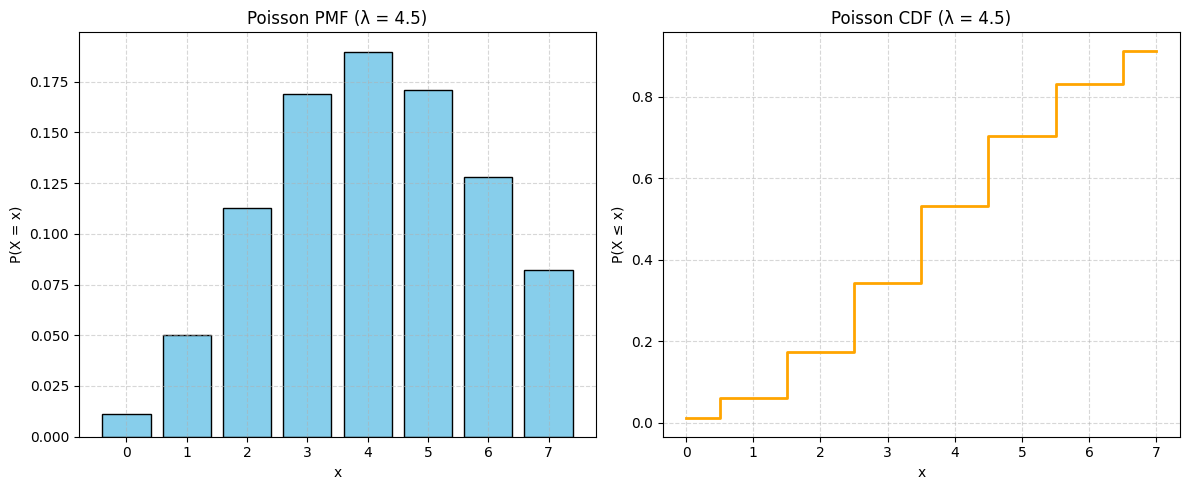

In [14]:
# Create figure and axes
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# PMF plot
# Should look like a "bell curve" but with some skewness
# As lambda increases, it will look more like a normal distribution
ax[0].bar(x_vals, pmf_vals, color='skyblue', edgecolor='black')
ax[0].set_title(f'Poisson PMF (λ = {lambda_val})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, linestyle='--', alpha=0.5)

# CDF plot
# Poisson is a discrete distribution so it should look like a staircase
ax[1].step(x_vals, cdf_vals, where='mid', color='orange', linewidth=2)
ax[1].set_title(f'Poisson CDF (λ = {lambda_val})')
ax[1].set_xlabel('x')
ax[1].set_ylabel('P(X ≤ x)')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Binomial Distribution Calculations and Graphing
The last distribution that I will showcase in this 0.1 notebook (for now) is the binomial distribution. This is one of the more widely known distributions that is also super useful for modeling events over time.

There are a plethora of other distributions in our library that you can use, these are just a hand-selected few that I decided to choose as the best examples.

In [15]:
from fastdist.distributions import Binomial

# ============================================================================
# BINOMIAL DISTRIBUTION SHOWCASE
# ============================================================================
binom_dist = Binomial(n=10, p=0.3)

print("\n" + "=" * 80)
print("BINOMIAL DISTRIBUTION SHOWCASE")
print("=" * 80)

# PMF values for all possible outcomes
x_vals = list(range(0, binom_dist.n + 1))  # ensure integers otherwise we won't pass the type check
pmf_vals = [binom_dist.pmf_scalar(x) for x in x_vals]
cdf_vals = [binom_dist.cdf_scalar(x) for x in x_vals]

print(f"{'x':<4} {'PMF':<12} {'CDF':<12}")
print("-" * 32)
for x, pmf, cdf in zip(x_vals, pmf_vals, cdf_vals):
    print(f"{x:<4} {pmf:<12.6f} {cdf:<12.4f}")

# Summary stats
print("\nSummary Statistics:")
print(f"  Mean: {binom_dist.mean():.4f}")
print(f"  Variance: {binom_dist.variance():.4f}")
print(f"  Stddev: {binom_dist.stddev():.4f}")

# Sample a value
sample_val = binom_dist.sample()
print(f"  Sampled value: {sample_val}")

# Moment generating function at t=0.5
t = 0.5
mgf_val = binom_dist.mgf_scalar(t)
cgf_val = binom_dist.cgf_scalar(t)
print(f"  MGF(t={t}): {mgf_val:.4f}")
print(f"  CGF(t={t}): {cgf_val:.4f}")



BINOMIAL DISTRIBUTION SHOWCASE
x    PMF          CDF         
--------------------------------
0    0.028248     0.0282      
1    0.121061     0.1493      
2    0.233474     0.3828      
3    0.266828     0.6496      
4    0.200121     0.8497      
5    0.102919     0.9527      
6    0.036757     0.9894      
7    0.009002     0.9984      
8    0.001447     0.9999      
9    0.000138     1.0000      
10   0.000006     1.0000      

Summary Statistics:
  Mean: 3.0000
  Variance: 2.1000
  Stddev: 1.4491
  Sampled value: 5
  MGF(t=0.5): 5.9195
  CGF(t=0.5): 1.7783


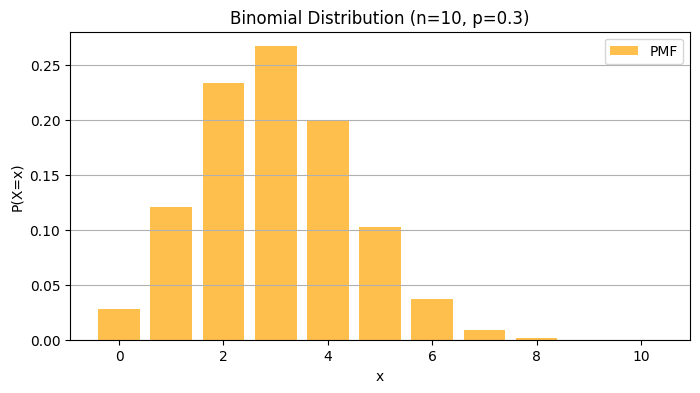

In [16]:
# Binomial plot
# This is also a discrete distribution, exactly like Poisson (but different properties)
# We would anticipate the highest probability at ~3 because that is the calculated mean
plt.figure(figsize=(8,4))
plt.bar(x_vals, pmf_vals, alpha=0.7, color='orange', label='PMF')
plt.title(f'Binomial Distribution (n={binom_dist.n}, p={binom_dist.p})')
plt.xlabel('x')
plt.ylabel('P(X=x)')
plt.grid(axis='y')
plt.legend()
plt.show()

## Basic Utilities (2)
Finally, I wanted to show off the rest of the (current) util functions just to give you an idea of how you can leverage them.

Much like I have mentioned a few times now, we will be constantly updating this as needed.

In [17]:
# ============================================================================
# 5. UTILITY FUNCTIONS FROM FASTDIST.UTILS (REMAINING)
# ============================================================================

print("\n" + "=" * 80)
print("5. UTILITY FUNCTIONS FROM FASTDIST.UTILS (REMAINING)")
print("=" * 80)

# Bayes Rule & Law of Total Probability
p_A = np.array([0.4, 0.6], dtype=np.float64)          # probabilities of A events
p_B_given_A = np.array([0.8, 0.2], dtype=np.float64)  # corresponding P(B|A)
p_B = 0.5

# Bayes Rule for first element
bayes_val = Utils.bayes_rule(p_B_given_A[0], p_A[0], p_B)

# Law of Total Probability for all elements
# Note that if you want to do single elements for total probability, they still must be in a length one list
tot_prob_val = Utils.law_of_total_probability(p_A, p_B_given_A)

print(f"\nBayes Rule: P(A|B) = {bayes_val:.4f}")
print(f"Law of Total Probability: P(B) = {tot_prob_val:.4f}")

# Sigmoid / Logit
x_val = 1.0
sig_val = Utils.sigmoid(x_val)
logit_val = Utils.logit(0.7)
print(f"\nSigmoid({x_val}) = {sig_val:.4f}")
print(f"Logit(0.7) = {logit_val:.4f}")

# Coefficient of variation
mean_val = 5.0
std_val = 1.2
cv_val = Utils.coefficient_of_variation(mean_val, std_val)
print(f"\nCoefficient of Variation: {cv_val:.4f}")

# Covariance example
mean_x = 2.0
mean_y = 3.0
E_xy = 6.5
cov_val = Utils.covariance(mean_x, mean_y, E_xy)
print(f"Covariance: {cov_val:.4f}")

# Gamma / log-gamma
x_val = 5.0
print(f"\nGamma({x_val}) = {Utils.gamma(x_val):.4f}")
print(f"Log Gamma({x_val}) = {Utils.log_gamma(x_val):.4f}")

# Pascal's binomial theorem 
n, a, b = 10, 2, 3   # a + b != 1
binom_val = Utils.binomial(n, a, b)
print(f"Binomial(n={n}, a={a}, b={b}) = {binom_val:.4f}")


5. UTILITY FUNCTIONS FROM FASTDIST.UTILS (REMAINING)

Bayes Rule: P(A|B) = 0.6400
Law of Total Probability: P(B) = 0.4400

Sigmoid(1.0) = 0.7311
Logit(0.7) = 0.8473

Coefficient of Variation: 0.2400
Covariance: 0.5000

Gamma(5.0) = 24.0000
Log Gamma(5.0) = 3.1781
Binomial(n=10, a=2, b=3) = 9765625.0000


## Conclusion
Thank you for reading this notebook and taking the time to look at our little showcase. We know it's not perfect at this stage, and we know that we have work to do, but we feel like we are learning a lot and doing a lot through building this library. 

We hope this can have some sort of positive impact, and that we can help to encourage the open-source philosophy in the programming community!

Special thanks to Zachery Pipes for his contributions on this library.

**Notebook by:** Manny McGrail